In [117]:
import pandas as pd
import matplotlib.pyplot as plt

In [118]:
df = pd.read_csv('..\..\Farm\DATA\d.csv', parse_dates=['timestamp'])

In [119]:
df.head()
df.describe()

,timestamp,raw_weight_kg
count,5000,5000.000000
mean,2025-08-17 12:56:35,1.490723
min,2025-08-17 06:00:00,-0.150976
25%,2025-08-17 09:28:17.500000,0.065906
50%,2025-08-17 12:56:35,1.447337
75%,2025-08-17 16:24:52.500000,2.292677
max,2025-08-17 19:53:10,4.956841
std,NaN,1.189107


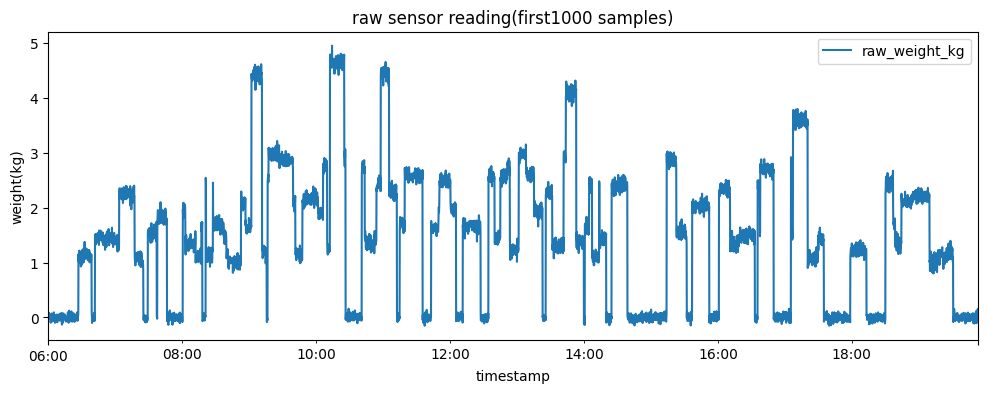

In [120]:
df.plot(x='timestamp', y='raw_weight_kg', figsize=(12,4))
plt.ylabel('weight(kg)')
plt.title('raw sensor reading(first1000 samples)')
plt.show()


In [121]:
import numpy as np


In [122]:
occupied = df["raw_weight_kg"] > 0.93 # Boolean mask
df["occupied"] = occupied.astype(int)

# Find transitions
df["shift"] = df["occupied"].diff().fillna(0)

event_starts = df.index[df["shift"] == 1].tolist()
event_ends   = df.index[df["shift"] == -1].tolist()

#Handle case where plate occupied at the end
if len(event_ends) < len(event_starts):
    event_ends.append(df.index[-1])

events = list(zip(event_starts, event_ends))
print("Detected events:", len(events))


Detected events: 45


In [123]:
print(events)

[(163, 176), (177, 234), (252, 499), (501, 511), (536, 584), (587, 639), (724, 829), (847, 870), (871, 968), (969, 972), (973, 993), (994, 998), (999, 1000), (1001, 1007), (1008, 1016), (1017, 1019), (1020, 1022), (1024, 1031), (1032, 1175), (1180, 1599), (1686, 1875), (1890, 2013), (2059, 2193), (2229, 2325), (2367, 2658), (2675, 2880), (2885, 3000), (3029, 3114), (3325, 3433), (3462, 3554), (3606, 3799), (3814, 3900), (3993, 4083), (4084, 4124), (4125, 4170), (4312, 4399), (4501, 4740), (4741, 4749), (4750, 4754), (4755, 4760), (4761, 4767), (4768, 4769), (4770, 4778), (4779, 4812), (4813, 4865)]


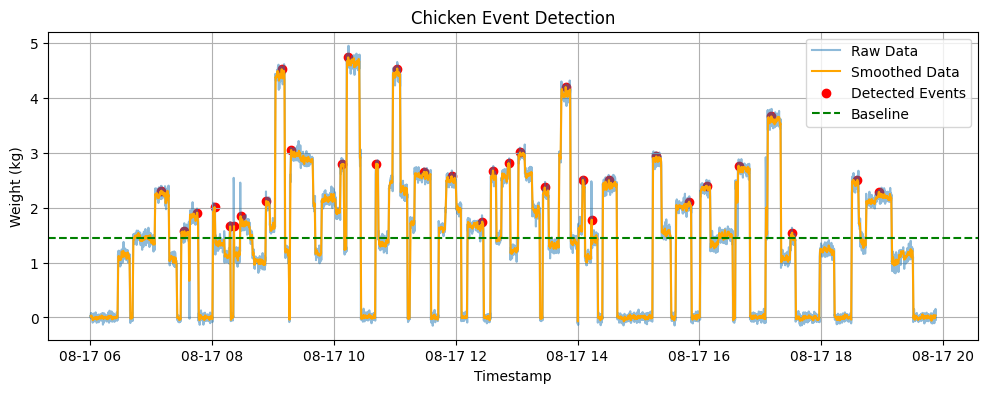

Detected 33 potential chicken events


In [124]:
from scipy.signal import find_peaks
# Smooth the data to reduce noise (moving average)
window_size = 5  # Adjust based on your data frequency
df['smoothed_weight'] = df['raw_weight_kg'].rolling(window=window_size, center=True).mean()

# Calculate baseline (median works well for this type of data)
baseline = df['raw_weight_kg'].median()

# Detect peaks - these are our chicken events
peaks, properties = find_peaks(
    df['smoothed_weight'],
    height=baseline,  # Threshold above baseline (adjust based on your data)
    distance=1,         # Minimum samples between peaks (adjust based on chicken behavior)
    prominence=0.5       # How much the peak stands out (adjust based on your data)
)

# Plot the results
plt.figure(figsize=(12, 4))
plt.plot(df['timestamp'], df['raw_weight_kg'], label='Raw Data', alpha=0.5)
plt.plot(df['timestamp'], df['smoothed_weight'], label='Smoothed Data', color='orange')
plt.scatter(df['timestamp'].iloc[peaks], df['smoothed_weight'].iloc[peaks], 
            color='red', label='Detected Events')
plt.axhline(y=baseline, color='green', linestyle='--', label='Baseline')
plt.xlabel('Timestamp')
plt.ylabel('Weight (kg)')
plt.title('Chicken Event Detection')
plt.legend()
plt.grid(True)
plt.show()

print(f"Detected {len(peaks)} potential chicken events")

            timestamp  max_weight  duration  area_under_curve  rise_time  \
0 2025-08-17 07:10:00    2.401411       2.0         15.655706        0.8   
1 2025-08-17 07:32:40    1.719268       2.0          1.105007        0.9   
2 2025-08-17 07:45:10    1.985666       2.0          4.342413        0.9   
3 2025-08-17 08:02:20    2.092091       2.0          6.118316        0.3   
4 2025-08-17 08:17:40    1.739639       2.0        -11.030016        1.2   

   baseline  
0  1.447337  
1  1.447337  
2  1.447337  
3  1.447337  
4  1.447337  


C:\Users\dipes\AppData\Local\Temp\ipykernel_93400\4086866636.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  'area_under_curve': np.trapz(event_data['raw_weight_kg'] - baseline),


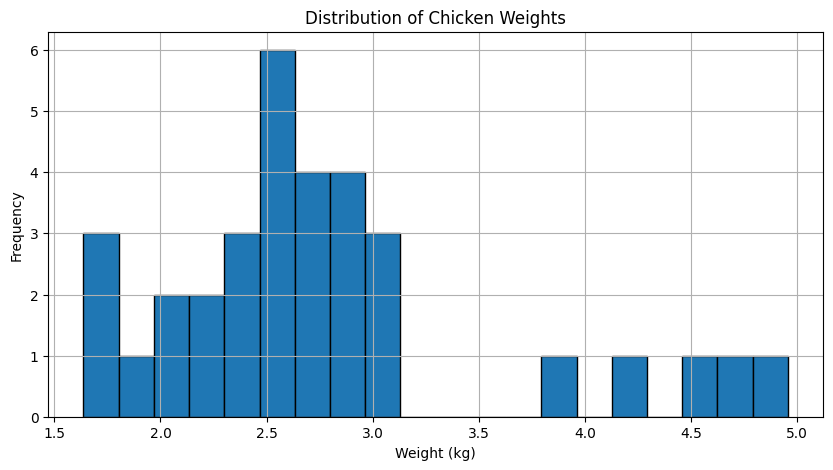

In [125]:
# Extract features from each detected event
event_features = []
for peak in peaks:
    event_start = max(0, peak - 10)  # Look 10 samples before peak
    event_end = min(len(df), peak + 10)  # Look 10 samples after peak
    
    event_data = df.iloc[event_start:event_end]
    
    features = {
        'timestamp': df['timestamp'].iloc[peak],
        'max_weight': event_data['raw_weight_kg'].max(),
        'duration': len(event_data) / 10,  # Assuming 10Hz sampling rate
        'area_under_curve': np.trapz(event_data['raw_weight_kg'] - baseline),
        'rise_time': np.argmax(event_data['raw_weight_kg']) / 10,  # Time to peak
        'baseline': baseline
    }
    event_features.append(features)

# Create a DataFrame of events
events_df = pd.DataFrame(event_features)
print(events_df.head())

# Plot histogram of event weights
plt.figure(figsize=(10, 5))
plt.hist(events_df['max_weight'], bins=20, edgecolor='black')
plt.xlabel('Weight (kg)')
plt.ylabel('Frequency')
plt.title('Distribution of Chicken Weights')
plt.grid(True)
plt.show()

Optimal number of clusters: 2


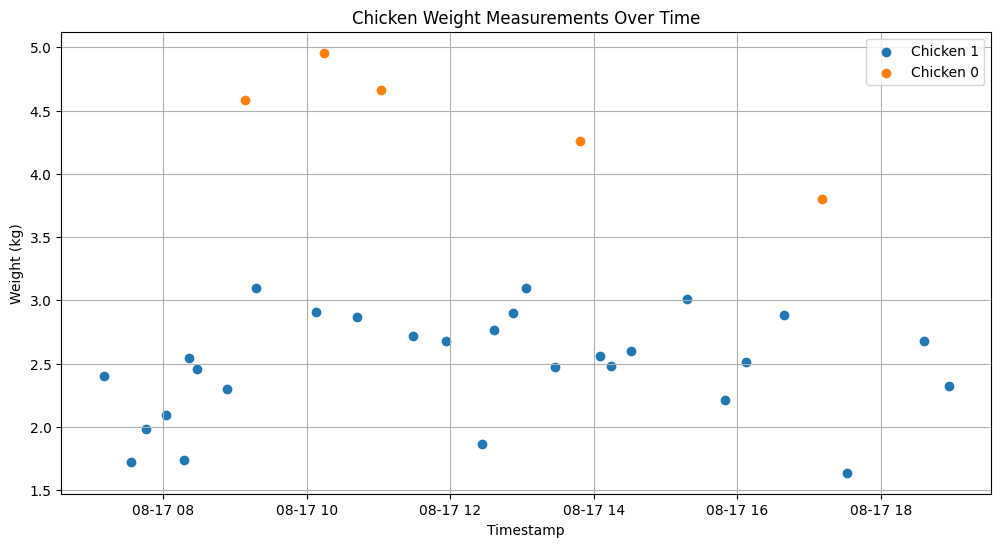

In [126]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Cluster the weights to estimate number of chickens
weights = events_df[['max_weight']].values

# Determine optimal number of clusters using silhouette score
range_n_clusters = range(2, 6)
best_score = -1
best_n = 2

for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = clusterer.fit_predict(weights)
    silhouette_avg = silhouette_score(weights, cluster_labels)
    
    if silhouette_avg > best_score:
        best_score = silhouette_avg
        best_n = n_clusters

print(f"Optimal number of clusters: {best_n}")

# Fit with optimal clusters
kmeans = KMeans(n_clusters=best_n, random_state=42)
events_df['chicken_id'] = kmeans.fit_predict(weights)

# Plot clustered weights over time
plt.figure(figsize=(12, 6))
for chicken_id in events_df['chicken_id'].unique():
    chicken_data = events_df[events_df['chicken_id'] == chicken_id]
    plt.scatter(chicken_data['timestamp'], chicken_data['max_weight'], 
                label=f'Chicken {chicken_id}')

plt.xlabel('Timestamp')
plt.ylabel('Weight (kg)')
plt.title('Chicken Weight Measurements Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [127]:
print(weights)
print(weights.shape)

[[2.40141103]
 [1.71926822]
 [1.98566635]
 [2.09209073]
 [1.73963918]
 [2.54677058]
 [2.45924032]
 [2.29820345]
 [4.58056192]
 [3.09427719]
 [2.90966883]
 [4.95684105]
 [2.86928532]
 [4.66025769]
 [2.72068271]
 [2.68047166]
 [1.86447691]
 [2.76168545]
 [2.90187313]
 [3.09689429]
 [2.47224995]
 [4.2574298 ]
 [2.55590112]
 [2.48382913]
 [2.59956521]
 [3.01351775]
 [2.2107476 ]
 [2.51041842]
 [2.88373956]
 [3.80417624]
 [1.63680588]
 [2.67602652]
 [2.32180826]]
(33, 1)


In [134]:
silhouette_avg = np.mean(weights, axis=0)
print(f"Average weight: {silhouette_avg[0]:.3f} kg")

Average weight: 2.781 kg
